# Building the kilonova transformer — a tutorial

`openuniverse_dataset.py` turns each transient's early light curve into a small **set of
tokens**: one per (band × visit), each carrying its time, band, magnitude, and a type flag
(detection `d` / 5σ upper limit `u` / instrumental gap `n`), plus one global redshift token
`[Z]`. This notebook builds, from scratch and step by step, the **encoder-only transformer**
that classifies those token sets into `{Ia, II, other, KN}`.

The data are the **OpenUniverse early windows** — Roman contaminants from
`generate_early_windows.py` plus injected LANL kilonovas from `generate_kilonova_hdf5`
(`kilonova_dataloader.ipynb`). The sample loaded here is a small **placeholder**; it grows
without any change to the loader or the model.

It is modelled on the [UvA DL tutorial 6 — *Transformers and Multi-Head Attention*](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial6/Transformers_and_MHAttention.html)
(`scaled_dot_product` → `MultiheadAttention` → `EncoderBlock` → `TransformerEncoder`), with
two physics-driven changes for our problem:

- **No order-based positional encoding.** Our tokens are a *set indexed by physical time*, not
  an ordered sentence. Time enters as a continuous feature *inside* each token.
- **Time encoding tuned for decay, not periodicity.** With at most 3 epochs over ~15 days there
  is no light-curve *modulation* to resolve (these are transients, not pulsating stars). The
  discriminative physics is the **decline rate** (Δmag/Δt — a kilonova fades in days, a
  supernova in weeks) together with the **detection / non-detection pattern** (a source that
  drops below 5σ between epochs is kilonova-like). The time encoding is built so attention can
  read off *decline rates*; we deliberately keep almost no periodic content.

**Scope.** We build the architecture, run a forward pass on a real batch, visualize the
attention, and finish with an *overfit-one-batch* check that proves the model is wired correctly
and can learn. Training on the real split, the on-the-fly KN injection, and the
early-classification degradation matrix are the next notebook.

In [1]:
%matplotlib inline
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# --- model size (plan.md: 2-4 layers, d_model 64-128, 4 heads) ---
D_MODEL = 64
NUM_HEADS = 4
NUM_LAYERS = 2
D_FEEDFORWARD = 128
DROPOUT = 0.1
NUM_CLASSES = 4

# --- token vocabulary ---
NUM_BANDS = 6
NUM_TOKEN_TYPES = 3
D_BAND = 16
D_TYPE = 16

# --- time encoding ---
TIME2VEC_FREQUENCIES = 6
DELTA_TIME_SCALE = 5.0  # the 5-day cadence; conditions raw Delta t before the time encoding

# --- redshift token: continuous z + a coarse low/high/unknown regime (see openuniverse_dataset.py) ---
REDSHIFT_THRESHOLD = 0.5
REDSHIFT_REGIME_ORDER = ['low', 'high', 'unknown']  # 'unknown' replaces the old [NO_Z] occultation
NUM_REDSHIFT_REGIMES = len(REDSHIFT_REGIME_ORDER)

BAND_ORDER = ['R', 'Z', 'Y', 'J', 'H', 'F']
TOKEN_TYPE_ORDER = ['d', 'u', 'n']
GROUP_ORDER = ['Ia', 'II', 'other', 'KN']

BAND_TO_INDEX = {band: index for index, band in enumerate(BAND_ORDER)}
TOKEN_TYPE_TO_INDEX = {token_type: index for index, token_type in enumerate(TOKEN_TYPE_ORDER)}

# the per-object dict the dataloader (collate_token_windows in openuniverse_dataset.py) emits
PER_TOKEN_KEYS = [
    'delta_time', 'band_index', 'token_type_index',
    'magnitude', 'sigma_magnitude', 'magnitude_mask', 'sigma_mask',
]
GLOBAL_KEYS = ['redshift', 'redshift_regime']

BAND_COLORS = {
    band: plt.cm.turbo(position)
    for band, position in zip(BAND_ORDER, np.linspace(0.05, 0.95, len(BAND_ORDER)))
}
TOKEN_MARKERS = {'d': 'o', 'u': 'v', 'n': 's'}
TOKEN_LABELS = {'d': 'detection', 'u': '5 sigma upper limit', 'n': 'not observed'}

print(f'torch {torch.__version__}  |  numpy {np.__version__}')

torch 2.12.0  |  numpy 2.4.1


## The batch contract

The model consumes exactly what `collate_token_windows` (`openuniverse_dataset.py`) produces —
nothing more. Per batch of `B` objects, padded to the longest token sequence `T`:

| key | shape | dtype | meaning |
|---|---|---|---|
| `delta_time` | `(B, T)` | float | days since first detection (Δt = 0 at the anchor) |
| `band_index` | `(B, T)` | long | index into `R Z Y J H F` |
| `token_type_index` | `(B, T)` | long | `0=d` detection, `1=u` 5σ upper limit, `2=n` gap |
| `magnitude`, `sigma_magnitude` | `(B, T)` | float | globally-normalized; `0` where masked |
| `magnitude_mask`, `sigma_mask` | `(B, T)` | float | `1` if that channel carries information |
| `padding_mask` | `(B, T)` | bool | `True` = padded slot the attention must ignore |
| `redshift` | `(B,)` | float | continuous truth z fed into the `[Z]` token (gated off when the regime is `unknown`) |
| `redshift_regime` | `(B,)` | long | coarse bin: `0=low` (z<0.5), `1=high` (z≥0.5), `2=unknown` (z-dropout) |
| `label` | `(B,)` | long | target class in `GROUP_ORDER`, mapped from the parquet/hdf5 `label` column |

`build_dataloaders` splits the early windows by `object_id` (no object leaks across
train/val/test), fits the magnitude/σ normalization on **train** only, and returns the three
loaders. `next(iter(train_loader))` yields this dict; the `[CLS]` and `[Z]` tokens are prepended
by the model itself.

objects: 74139   train/val/test batches: 3244/696/696
normalization: {'mag_mean': 25.856, 'mag_std': 0.866, 'sigma_mean': 0.118, 'sigma_std': 0.057}
batch keys and shapes:
  delta_time         (16, 20)  torch.float32
  band_index         (16, 20)  torch.int64
  token_type_index   (16, 20)  torch.int64
  magnitude          (16, 20)  torch.float32
  sigma_magnitude    (16, 20)  torch.float32
  magnitude_mask     (16, 20)  torch.float32
  sigma_mask         (16, 20)  torch.float32
  padding_mask       (16, 20)  torch.bool
  redshift           (16,)  torch.float32
  redshift_regime    (16,)  torch.int64
  label              (16,)  torch.int64
labels: ['Ia', 'II', 'Ia', 'II', 'other', 'II', 'II', 'II', 'II', 'other', 'Ia', 'Ia', 'other', 'Ia', 'II', 'Ia']


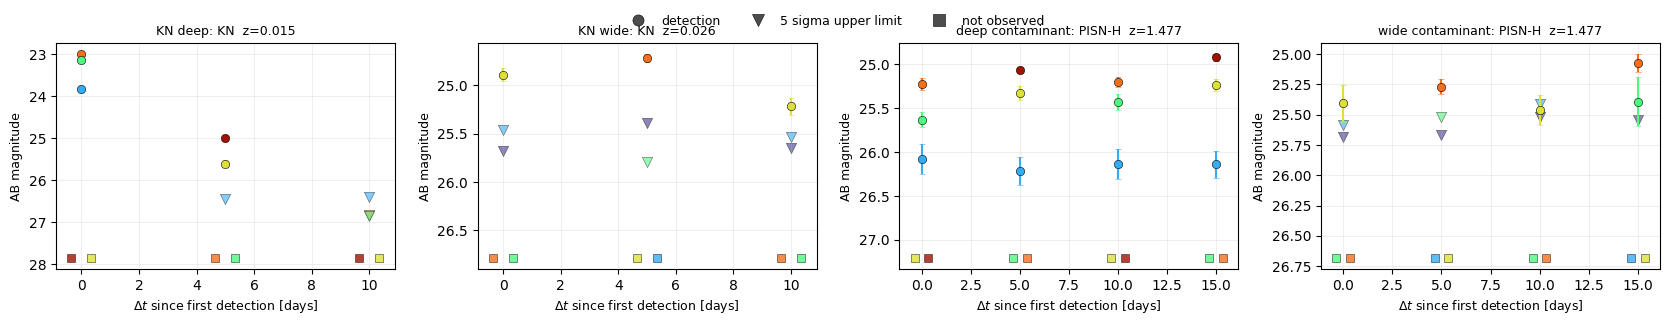

In [2]:
from kilonova.config import load_paths

import pandas as pd

from kilonova.datasets.openuniverse import (
    load_early_windows, load_kilonova_windows, build_dataloaders, EarlyWindowDataset,
    collate_token_windows, GROUP_ORDER as DATA_GROUP_ORDER,
)

assert DATA_GROUP_ORDER == GROUP_ORDER, 'class order must match the model classification head'

# Real early windows: OpenUniverse contaminants (generate_early_windows.py) + injected kilonovas
# (generate_kilonova_hdf5 in kilonova_dataloader.ipynb, one HDF5 per tier). Small placeholder sample for
# now; the same call scales unchanged as more windows are generated.
EARLY_WINDOW_PARQUETS = [
    str(load_paths().output_dir / 'early_windows_deep.parquet'),
    str(load_paths().output_dir / 'early_windows_wide.parquet'),
]
KN_HDF5_PATHS = [
    str(load_paths().output_dir / 'kilonova_windows_deep.hdf5'),
    str(load_paths().output_dir / 'kilonova_windows_wide.hdf5'),
]

long_df = pd.concat(
    [load_early_windows(EARLY_WINDOW_PARQUETS)]
    + [load_kilonova_windows(path) for path in KN_HDF5_PATHS],
    ignore_index=True,
)
loaders, normalization = build_dataloaders(long_df, batch_size=16, random_seed=0)
train_loader, validation_loader, test_loader = loaders['train'], loaders['validation'], loaders['test']

batch = next(iter(train_loader))

# Two objects to follow through the notebook: a kilonova (if the batch has one) and a contaminant.
batch_labels = batch['label']
kilonova_positions = (batch_labels == GROUP_ORDER.index('KN')).nonzero(as_tuple=True)[0]
EXAMPLE_INDEX = int(kilonova_positions[0]) if len(kilonova_positions) else 0
contaminant_positions = (batch_labels != batch_labels[EXAMPLE_INDEX]).nonzero(as_tuple=True)[0]
EXAMPLE_INDEX_B = int(contaminant_positions[0]) if len(contaminant_positions) else 0


def plot_batch_light_curves(batch, normalization, indices, ncols=4, titles=None, plot=True):
    '''De-normalize the token magnitudes back to AB mag and draw each object's early window:
    o detection (with error bar), v 5-sigma upper limit, square = not observed at that visit. All gap
    squares sit one magnitude fainter than the object's faintest observation, spread horizontally within
    an epoch so they neither overlap each other nor the data.'''
    indices = list(indices)
    number_of_rows = int(np.ceil(len(indices) / ncols))
    figure, axes = plt.subplots(number_of_rows, ncols,
                                figsize=(4.2 * ncols, 3.2 * number_of_rows), squeeze=False)
    for axis_position, object_index in enumerate(indices):
        axis = axes[axis_position // ncols][axis_position % ncols]
        keep = ~batch['padding_mask'][object_index]
        delta_time = batch['delta_time'][object_index][keep].numpy()
        band_index = batch['band_index'][object_index][keep].numpy()
        token_type_index = batch['token_type_index'][object_index][keep].numpy()
        magnitude_mask = batch['magnitude_mask'][object_index][keep].numpy().astype(bool)
        sigma_mask = batch['sigma_mask'][object_index][keep].numpy().astype(bool)
        magnitude = np.where(
            magnitude_mask,
            batch['magnitude'][object_index][keep].numpy() * normalization['mag_std'] + normalization['mag_mean'],
            np.nan,
        )
        sigma = np.where(
            sigma_mask,
            batch['sigma_magnitude'][object_index][keep].numpy() * normalization['sigma_std'] + normalization['sigma_mean'],
            np.nan,
        )
        # Faintest observation (detection or upper limit) in the whole window -> all gap squares 1 mag below.
        finite = np.isfinite(magnitude)
        square_magnitude = (magnitude[finite].max() + 1.0) if finite.any() else 25.0

        gaps_by_epoch = {}
        for time_value, band, token_type_value, magnitude_value, sigma_value in zip(
            delta_time, band_index, token_type_index, magnitude, sigma,
        ):
            color = BAND_COLORS[BAND_ORDER[band]]
            token_type = TOKEN_TYPE_ORDER[token_type_value]
            if token_type == 'd':
                axis.errorbar(time_value, magnitude_value, yerr=sigma_value, fmt='o', color=color,
                              markersize=6, markeredgecolor='black', markeredgewidth=0.4, capsize=2)
            elif token_type == 'u':
                axis.scatter(time_value, magnitude_value, marker='v', color=color, s=55,
                             edgecolor='black', linewidth=0.4, alpha=0.6)
            else:
                gaps_by_epoch.setdefault(time_value, []).append(band)
        for epoch_time, gap_bands in gaps_by_epoch.items():
            count = len(gap_bands)
            for position, band in enumerate(gap_bands):
                offset = (position - (count - 1) / 2) * 0.7
                axis.scatter(epoch_time + offset, square_magnitude, marker='s',
                             facecolor=BAND_COLORS[BAND_ORDER[band]], edgecolor='black',
                             linewidth=0.4, s=30, alpha=0.8, zorder=5)
        axis.invert_yaxis()
        axis.set_xlabel(r'$\Delta t$ since first detection [days]', fontsize=9)
        axis.set_ylabel('AB magnitude', fontsize=9)
        if titles is not None:
            axis.set_title(titles[axis_position], fontsize=9)
        else:
            label_name = GROUP_ORDER[int(batch['label'][object_index])]
            redshift = float(batch['redshift'][object_index])
            axis.set_title(f'obj {object_index}: {label_name}   z={redshift:.3f}', fontsize=9)
        axis.grid(alpha=0.2)
    for empty_position in range(len(indices), number_of_rows * ncols):
        axes[empty_position // ncols][empty_position % ncols].set_visible(False)

    marker_handles = [
        plt.Line2D([0], [0], marker=TOKEN_MARKERS[token_type], color='0.3', linestyle='none',
                   markersize=8, markeredgecolor='black', markeredgewidth=0.4, label=TOKEN_LABELS[token_type])
        for token_type in TOKEN_TYPE_ORDER
    ]
    figure.legend(handles=marker_handles, loc='upper center', ncol=3, frameon=False,
                  bbox_to_anchor=(0.5, 1.02), fontsize=9)
    plt.tight_layout()
    if plot:
        plt.show()


def example_window_batch(long_df, normalization):
    '''Open one window per (class, tier) — a kilonova and a contaminant in both deep and wide — and
    collate them into a batch, so we can eyeball that every source feeds the model the same way. Returns
    the batch and a per-panel title.'''
    selectors = [
        ('KN deep', (long_df['source'] == 'kn') & (long_df['tier'] == 'deep')),
        ('KN wide', (long_df['source'] == 'kn') & (long_df['tier'] == 'wide')),
        ('deep contaminant', long_df['source'] == 'deep'),
        ('wide contaminant', long_df['source'] == 'wide'),
    ]
    chosen_rows, titles = [], []
    for name, mask in selectors:
        candidates = long_df[mask]
        if candidates.empty:
            continue
        object_rows = long_df[long_df['object_id'] == candidates['object_id'].iloc[0]]
        chosen_rows.append(object_rows)
        info = object_rows.iloc[0]
        titles.append(f"{name}: {info['label']}  z={info['z_CMB']:.3f}")
    example_dataset = EarlyWindowDataset(pd.concat(chosen_rows, ignore_index=True), normalization)
    example_batch = collate_token_windows([example_dataset[index] for index in range(len(example_dataset))])
    return example_batch, titles


print(f'objects: {long_df["object_id"].nunique()}   '
      f'train/val/test batches: {len(train_loader)}/{len(validation_loader)}/{len(test_loader)}')
print(f'normalization: { {key: round(value, 3) for key, value in normalization.items()} }')
print('batch keys and shapes:')
for key, tensor in batch.items():
    print(f'  {key:18s} {tuple(tensor.shape)}  {tensor.dtype}')
print('labels:', [GROUP_ORDER[index] for index in batch['label'].tolist()])

# Open one window per source and plot them side by side.
example_batch, example_titles = example_window_batch(long_df, normalization)
plot_batch_light_curves(example_batch, normalization, range(len(example_titles)), ncols=4, titles=example_titles)

## 1 — Scaled dot-product attention

Attention is a content-based lookup. Each token emits a **query**, every token a **key** and a
**value**; the query is compared (dot product) against all keys to produce weights, and the
output is the weighted sum of values. There is no notion of order — exactly what we want, since
our tokens are a *set*.

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

The $\sqrt{d_k}$ scaling keeps the logits from growing with dimension (which would saturate the
softmax). Two adaptations versus the textbook version:

- **Padding mask.** Batched objects are padded to a common length; padded *keys* must be
  unreachable. We add $-\infty$ to their logits before the softmax so their weight is zero.
- **We return the attention weights**, so we can later inspect what the `[CLS]` token reads.

This is the only place attention can turn the raw tokens into the physics we care about: by
comparing two same-band tokens at different Δt it can form a **decline rate**, and by reading a
detection next to later upper-limit tokens it sees a **fast fade**.

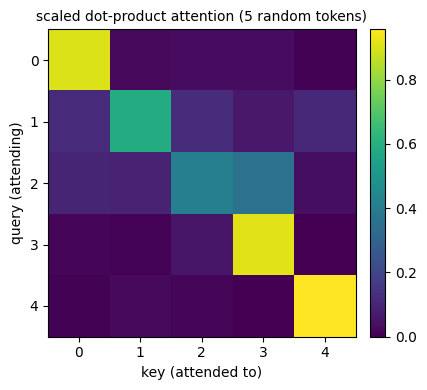

In [3]:
def scaled_dot_product(query, key, value, mask=None):
    '''Attention for tensors shaped (..., sequence_length, head_dimension).

    mask uses 1 = keep, 0 = ignore (padded key); masked logits go to -inf before the softmax.
    Returns (values, attention_weights).
    '''
    head_dimension = query.size(-1)
    attention_logits = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(head_dimension)
    if mask is not None:
        attention_logits = attention_logits.masked_fill(mask == 0, -9e15)
    attention_weights = F.softmax(attention_logits, dim=-1)
    values = torch.matmul(attention_weights, value)
    return values, attention_weights


def plot_attention_matrix(attention_weights, token_labels=None, title='', axis=None):
    created_axis = axis is None
    if created_axis:
        figure, axis = plt.subplots(figsize=(4.5, 4.0))
    image = axis.imshow(attention_weights, cmap='viridis', vmin=0.0)
    if token_labels is not None:
        axis.set_xticks(range(len(token_labels)))
        axis.set_xticklabels(token_labels, rotation=90, fontsize=8)
        axis.set_yticks(range(len(token_labels)))
        axis.set_yticklabels(token_labels, fontsize=8)
    axis.set_xlabel('key (attended to)')
    axis.set_ylabel('query (attending)')
    axis.set_title(title, fontsize=10)
    if created_axis:
        plt.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()
    return image


def demo_scaled_dot_product(plot=True):
    torch.manual_seed(1)
    sequence_length, dimension = 5, 8
    query = torch.randn(1, sequence_length, dimension)
    _, attention_weights = scaled_dot_product(query, query, query)
    if plot:
        plot_attention_matrix(attention_weights[0].detach().numpy(),
                              title='scaled dot-product attention (5 random tokens)')
    return attention_weights


_ = demo_scaled_dot_product(plot=True)

## 2 — Multi-head attention

One attention pattern is limiting: the model may need to compare *the same band across time*
(to get a decline rate) **and** *different bands at the same time* (to get a color) **and**
*detections against upper limits* (to spot a fade) — all at once. Multi-head attention runs `h`
attention operations in parallel on `h` learned projections of the tokens, so different heads
can specialize, then concatenates them.

We follow the UvA tutorial: a single linear layer produces all queries, keys and values
($3\,d_{\text{model}}$ wide), we reshape into `(batch, heads, sequence, head_dim)`, apply
`scaled_dot_product` per head, then a final output projection mixes the heads back together.
The padding mask is broadcast over the head and query axes — it only depends on *which key* is
padded.

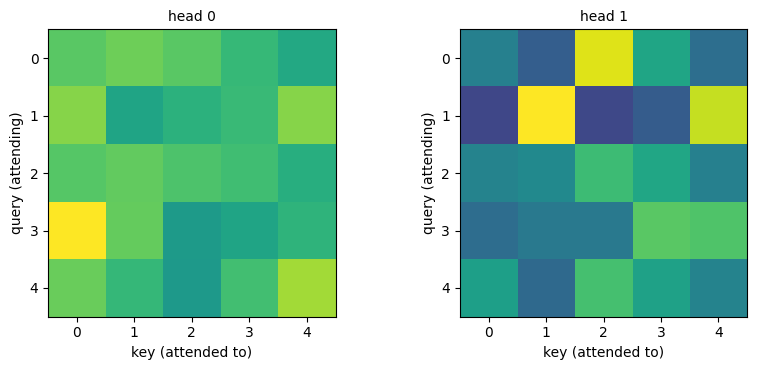

In [4]:
class MultiheadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dimension = d_model // num_heads
        self.qkv_projection = nn.Linear(d_model, 3 * d_model)
        self.output_projection = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None, return_attention=False):
        batch_size, sequence_length, _ = x.shape
        qkv = self.qkv_projection(x)
        qkv = qkv.reshape(batch_size, sequence_length, self.num_heads, 3 * self.head_dimension)
        qkv = qkv.permute(0, 2, 1, 3)
        query, key, value = qkv.chunk(3, dim=-1)
        values, attention_weights = scaled_dot_product(query, key, value, mask=mask)
        values = values.permute(0, 2, 1, 3).reshape(batch_size, sequence_length, self.d_model)
        output = self.output_projection(values)
        if return_attention:
            return output, attention_weights
        return output


def demo_multihead_attention(plot=True):
    torch.manual_seed(2)
    demo_heads, demo_dimension, sequence_length = 2, 8, 5
    attention_module = MultiheadAttention(demo_dimension, demo_heads)
    x = torch.randn(1, sequence_length, demo_dimension)
    _, attention_weights = attention_module(x, return_attention=True)
    if plot:
        figure, axes = plt.subplots(1, demo_heads, figsize=(4.2 * demo_heads, 3.8))
        for head_index in range(demo_heads):
            plot_attention_matrix(attention_weights[0, head_index].detach().numpy(),
                                  title=f'head {head_index}', axis=axes[head_index])
        plt.tight_layout()
        plt.show()
    return attention_weights


_ = demo_multihead_attention(plot=True)

## 3 — Encoding time: decline, not modulation

A standard transformer adds a **positional encoding** — a bank of sines and cosines of the
token *index* — to inject order. We do **not** want that: our tokens have no order, and their
index is meaningless. What is meaningful is the *physical time* Δt of each visit.

We encode Δt with **time2vec** (Kazemi et al. 2019):

$$\text{time2vec}(\Delta t) = \big[\;\underbrace{\omega_0\,\Delta t + \varphi_0}_{\text{linear}},\;
\underbrace{\sin(\omega_1 \Delta t + \varphi_1),\,\dots,\,\sin(\omega_k \Delta t + \varphi_k)}_{\text{periodic}}\;\big]$$

The split matters for our physics:

- The **linear term** is the workhorse. It makes Δt available as a quantity attention can
  *difference*: comparing two tokens gives Δmag and Δt, hence the **decline rate** — the single
  most discriminative feature (kilonova: ~1 mag/day; supernova: ~0.05 mag/day).
- The **periodic terms** would capture a *modulation* (a pulsation, an orbit). Over 3 epochs in
  ~15 days there is nothing periodic to fit and no physical periodicity to expect, so we keep
  only a **few low-frequency** components (periods comparable to the window) and initialize the
  linear weight to dominate. **No high-frequency Fourier modulation.**

Contrast this with the UvA tutorial's `PositionalEncoding`, which is *fixed* high-to-low
frequency sinusoids of the integer position — the opposite of what a 3-epoch transient needs.

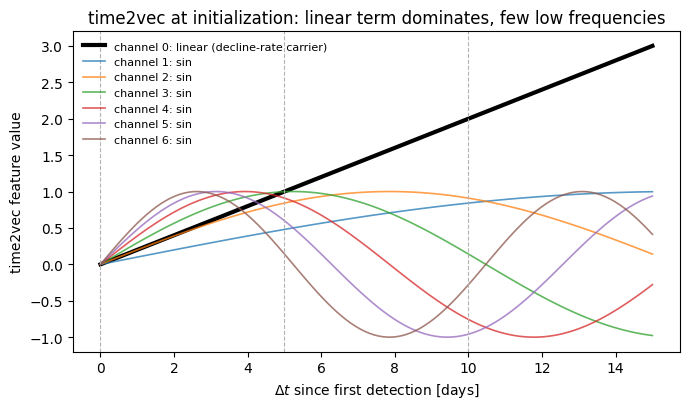

In [5]:
class Time2Vec(nn.Module):
    '''Continuous time encoding. Channel 0 is linear in Delta t (the decline-rate carrier); the
    remaining channels are a few low-frequency sinusoids. A final linear layer lifts the
    (num_frequencies + 1) features to output_dimension.'''

    def __init__(self, num_frequencies, output_dimension, delta_time_scale=DELTA_TIME_SCALE):
        super().__init__()
        self.delta_time_scale = delta_time_scale
        self.linear_weight = nn.Parameter(torch.ones(1))
        self.linear_bias = nn.Parameter(torch.zeros(1))
        # low frequencies: in scaled-time units, periods ~ 2 to 12 (i.e. ~10-60 d unscaled)
        self.frequency_weight = nn.Parameter(torch.linspace(0.5, 3.0, num_frequencies))
        self.frequency_bias = nn.Parameter(torch.zeros(num_frequencies))
        self.projection = nn.Linear(num_frequencies + 1, output_dimension)

    def time_features(self, delta_time):
        scaled_time = (delta_time / self.delta_time_scale).unsqueeze(-1)
        linear_term = self.linear_weight * scaled_time + self.linear_bias
        periodic_terms = torch.sin(scaled_time * self.frequency_weight + self.frequency_bias)
        return torch.cat([linear_term, periodic_terms], dim=-1)

    def forward(self, delta_time):
        return self.projection(self.time_features(delta_time))


def plot_time2vec(time2vec_module, plot=True):
    delta_time = torch.linspace(0.0, 15.0, 120)
    with torch.no_grad():
        features = time2vec_module.time_features(delta_time).numpy()
    if plot:
        figure, axis = plt.subplots(figsize=(7.0, 4.2))
        axis.plot(delta_time.numpy(), features[:, 0], color='black', lw=3,
                  label='channel 0: linear (decline-rate carrier)')
        for channel_index in range(1, features.shape[1]):
            axis.plot(delta_time.numpy(), features[:, channel_index], lw=1.2, alpha=0.75,
                      label=f'channel {channel_index}: sin')
        for epoch_delta_time in [0.0, 5.0, 10.0]:
            axis.axvline(epoch_delta_time, color='0.7', ls='--', lw=0.8)
        axis.set_xlabel(r'$\Delta t$ since first detection [days]')
        axis.set_ylabel('time2vec feature value')
        axis.set_title('time2vec at initialization: linear term dominates, few low frequencies')
        axis.legend(fontsize=8, loc='upper left', frameon=False)
        plt.tight_layout()
        plt.show()
    return features


_ = plot_time2vec(Time2Vec(TIME2VEC_FREQUENCIES, D_MODEL), plot=True)

## 4 — From token fields to a d_model vector

Each token's fields are embedded and **fused** into one `d_model` vector:

- `band_index` → a learned **band embedding** (color identity).
- `token_type_index` → a learned **type embedding** over `{d, u, n}`. This is the channel that
  carries the **detection / non-detection structure** — co-equal with the decline rate as the
  kilonova discriminator. An object that goes `d → u → u` is fading fast.
- `(magnitude, σ_mag, magnitude_mask, sigma_mask)` → a small linear projection. The masks are
  passed in so the model can tell a *real* normalized 0 from an *absent* channel (`u` has no
  error, `n` has no magnitude).

These are concatenated and projected to `d_model`, LayerNorm-ed, and the **time2vec(Δt) code is
added** — exactly where a vanilla transformer would add its positional encoding.

Two **global tokens** are prepended, one per object (no time, no band):

- **`[CLS]`** — a learned vector whose final state we read out for classification.
- **`[Z]`** — the redshift, built from **two parts that are added**: the **continuous** `z`
  projected to `d_model`, plus a learned **regime embedding** over `{low, high, unknown}`
  (`low` = z < 0.5, `high` = z ≥ 0.5). The regime is the *robust, reproducible* part — a photo-z
  lands on the correct side of 0.5 even when imprecise, and z ≥ 0.5 already rules a KN out (a KN
  is undetectable beyond z ≈ 0.15). The continuous channel is **gated off** in the `unknown`
  regime, so `unknown` is exactly the old **`[NO_Z]`** occultation: when z is withheld
  (z-dropout) the token is the bare `unknown` embedding. z carries the physics
  *z × photometry → luminosity* (a mag-24 transient at z = 1 is too luminous to be a KN).

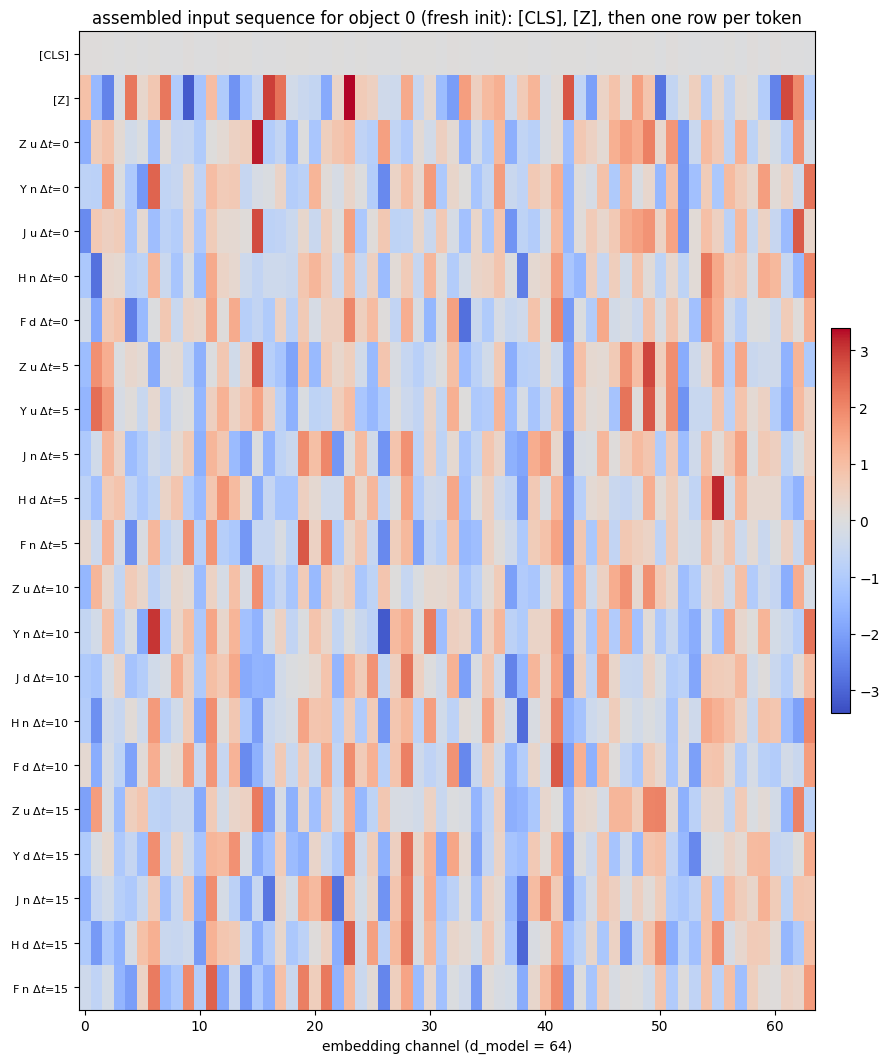

In [6]:
class TokenEmbedding(nn.Module):
    def __init__(self, d_model=D_MODEL):
        super().__init__()
        self.band_embedding = nn.Embedding(NUM_BANDS, D_BAND)
        self.token_type_embedding = nn.Embedding(NUM_TOKEN_TYPES, D_TYPE)
        self.magnitude_projection = nn.Linear(4, d_model)
        self.content_projection = nn.Linear(D_BAND + D_TYPE + d_model, d_model)
        self.content_norm = nn.LayerNorm(d_model)
        self.time_encoding = Time2Vec(TIME2VEC_FREQUENCIES, d_model)

    def forward(self, batch):
        band = self.band_embedding(batch['band_index'])
        token_type = self.token_type_embedding(batch['token_type_index'])
        magnitude_features = torch.stack(
            [batch['magnitude'], batch['sigma_magnitude'], batch['magnitude_mask'], batch['sigma_mask']],
            dim=-1,
        )
        magnitude = self.magnitude_projection(magnitude_features)
        content = torch.cat([band, token_type, magnitude], dim=-1)
        content = self.content_norm(self.content_projection(content))
        return content + self.time_encoding(batch['delta_time'])


class GlobalTokens(nn.Module):
    def __init__(self, d_model=D_MODEL):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.redshift_value_projection = nn.Linear(1, d_model)
        self.redshift_regime_embedding = nn.Embedding(NUM_REDSHIFT_REGIMES, d_model)

    def forward(self, batch):
        batch_size = batch['redshift'].shape[0]
        cls_token = self.cls_token.expand(batch_size, -1, -1)
        # [Z] = projected continuous z (gated off where the regime is 'unknown') + the regime embedding.
        # 'unknown' therefore reduces to the bare regime vector -- the old [NO_Z] occultation.
        regime = batch['redshift_regime']
        value_known = (regime != REDSHIFT_REGIME_ORDER.index('unknown')).float().unsqueeze(-1)
        redshift_value = self.redshift_value_projection(batch['redshift'].unsqueeze(-1)) * value_known
        regime_embedding = self.redshift_regime_embedding(regime)
        redshift_token = (redshift_value + regime_embedding).unsqueeze(1)
        return cls_token, redshift_token


def plot_assembled_sequence(batch, object_index=EXAMPLE_INDEX, plot=True):
    token_embedding = TokenEmbedding()
    global_tokens = GlobalTokens()
    with torch.no_grad():
        token_vectors = token_embedding(batch)
        cls_token, redshift_token = global_tokens(batch)
    keep = ~batch['padding_mask'][object_index]
    sequence = torch.cat(
        [cls_token[object_index], redshift_token[object_index], token_vectors[object_index][keep]],
        dim=0,
    ).detach().numpy()

    row_labels = ['[CLS]', '[Z]']
    for band_index, token_type_index, delta_time in zip(
        batch['band_index'][object_index][keep].numpy(),
        batch['token_type_index'][object_index][keep].numpy(),
        batch['delta_time'][object_index][keep].numpy(),
    ):
        row_labels.append(f'{BAND_ORDER[band_index]} {TOKEN_TYPE_ORDER[token_type_index]} '
                          rf'$\Delta t$={delta_time:.0f}')

    if plot:
        figure, axis = plt.subplots(figsize=(9.0, 0.42 * len(row_labels) + 1.5))
        limit = np.abs(sequence).max()
        image = axis.imshow(sequence, cmap='coolwarm', aspect='auto', vmin=-limit, vmax=limit)
        axis.set_yticks(range(len(row_labels)))
        axis.set_yticklabels(row_labels, fontsize=8)
        axis.set_xlabel(f'embedding channel (d_model = {sequence.shape[1]})')
        axis.set_title(f'assembled input sequence for object {object_index} (fresh init): '
                       f'[CLS], [Z], then one row per token')
        plt.colorbar(image, ax=axis, fraction=0.025, pad=0.02)
        plt.tight_layout()
        plt.show()
    return sequence


_ = plot_assembled_sequence(batch, object_index=EXAMPLE_INDEX, plot=True)

## 5 — The encoder block (pre-LayerNorm)

An encoder block is multi-head self-attention followed by a small position-wise MLP, each
wrapped in a residual connection. We use the **pre-LayerNorm** arrangement

$$x \leftarrow x + \text{MHA}(\text{LN}(x)), \qquad x \leftarrow x + \text{FFN}(\text{LN}(x))$$

rather than the UvA tutorial's post-LayerNorm. Pre-LN keeps a clean residual path and trains
more stably without a learning-rate warmup — worth it here, where we have only ~10k real
contaminants and a small model. The MLP is `Linear → GELU → Dropout → Linear` with an inner
width of `D_FEEDFORWARD`.

input (1, 6, 64) -> output (1, 6, 64) (shape preserved)
2 layers, each attention map (1, 4, 6, 6) (batch, heads, q, k)


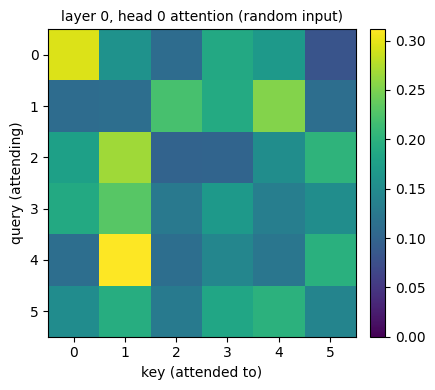

In [7]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, num_heads=NUM_HEADS, d_feedforward=D_FEEDFORWARD, dropout=DROPOUT):
        super().__init__()
        self.attention = MultiheadAttention(d_model, num_heads)
        self.attention_norm = nn.LayerNorm(d_model)
        self.feedforward_norm = nn.LayerNorm(d_model)
        self.feedforward = nn.Sequential(
            nn.Linear(d_model, d_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_feedforward, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attention_output = self.attention(self.attention_norm(x), mask=mask)
        x = x + self.dropout(attention_output)
        feedforward_output = self.feedforward(self.feedforward_norm(x))
        x = x + feedforward_output
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, num_layers=NUM_LAYERS, **block_kwargs):
        super().__init__()
        self.layers = nn.ModuleList([EncoderBlock(**block_kwargs) for _ in range(num_layers)])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask=mask)
        return x

    def get_attention_maps(self, x, mask=None):
        attention_maps = []
        for layer in self.layers:
            _, attention_weights = layer.attention(layer.attention_norm(x), mask=mask, return_attention=True)
            attention_maps.append(attention_weights)
            x = layer(x, mask=mask)
        return attention_maps


def demo_encoder(plot=True):
    torch.manual_seed(3)
    sequence_length = 6
    encoder = TransformerEncoder(num_layers=NUM_LAYERS, d_model=D_MODEL, num_heads=NUM_HEADS,
                                 d_feedforward=D_FEEDFORWARD, dropout=0.0)
    encoder.eval()
    x = torch.randn(1, sequence_length, D_MODEL)
    output = encoder(x)
    attention_maps = encoder.get_attention_maps(x)
    print(f'input {tuple(x.shape)} -> output {tuple(output.shape)} (shape preserved)')
    print(f'{len(attention_maps)} layers, each attention map {tuple(attention_maps[0].shape)} (batch, heads, q, k)')
    if plot:
        plot_attention_matrix(attention_maps[0][0, 0].detach().numpy(),
                              title='layer 0, head 0 attention (random input)')
    return output


_ = demo_encoder(plot=True)

## 6 — The full classifier

Now we assemble everything. Per batch:

1. Embed the per-token fields and add time2vec(Δt) → `(B, T, d_model)`.
2. Prepend `[CLS]` and `[Z]` → `(B, T+2, d_model)`.
3. Build the attention mask: the two global tokens are always valid; the per-token slots come
   from `~padding_mask`. The mask is shaped `(B, 1, 1, T+2)` so it zeroes out padded **keys** for
   every head and query.
4. Run the encoder, take the **`[CLS]`** output row, LayerNorm it, and project to the 4 class
   logits.

The transformer is justified here not by sequence length (we have ≤ 14 tokens) but by the
*structure*: missing bands, three token types, and a global z token that must interact with
every photometric token.

logits shape: (16, 4)   (B, num_classes)
trainable parameters: 75,042


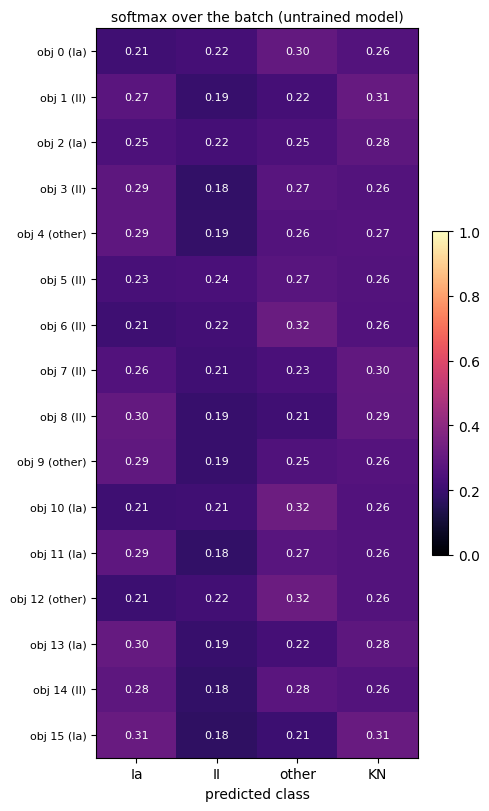

In [8]:
class KilonovaTransformer(nn.Module):
    def __init__(self, d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
                 d_feedforward=D_FEEDFORWARD, dropout=DROPOUT, num_classes=NUM_CLASSES):
        super().__init__()
        self.token_embedding = TokenEmbedding(d_model=d_model)
        self.global_tokens = GlobalTokens(d_model=d_model)
        self.input_dropout = nn.Dropout(dropout)
        self.encoder = TransformerEncoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads,
                                          d_feedforward=d_feedforward, dropout=dropout)
        self.classification_norm = nn.LayerNorm(d_model)
        self.classification_head = nn.Linear(d_model, num_classes)

    def _build_sequence_and_mask(self, batch):
        token_vectors = self.token_embedding(batch)
        cls_token, redshift_token = self.global_tokens(batch)
        sequence = torch.cat([cls_token, redshift_token, token_vectors], dim=1)
        sequence = self.input_dropout(sequence)

        batch_size, total_length, _ = sequence.shape
        token_valid = ~batch['padding_mask']
        global_valid = torch.ones(batch_size, 2, dtype=torch.bool, device=token_valid.device)
        valid = torch.cat([global_valid, token_valid], dim=1)
        attention_mask = valid.view(batch_size, 1, 1, total_length)
        return sequence, attention_mask

    def forward(self, batch):
        sequence, attention_mask = self._build_sequence_and_mask(batch)
        encoded = self.encoder(sequence, mask=attention_mask)
        cls_output = encoded[:, 0]
        return self.classification_head(self.classification_norm(cls_output))

    def attention_maps(self, batch):
        sequence, attention_mask = self._build_sequence_and_mask(batch)
        return self.encoder.get_attention_maps(sequence, mask=attention_mask)


def plot_class_probabilities(model, batch, title='softmax over the batch (untrained model)', plot=True):
    model.eval()
    with torch.no_grad():
        probabilities = F.softmax(model(batch), dim=-1).numpy()
    if plot:
        figure, axis = plt.subplots(figsize=(5.0, 0.42 * probabilities.shape[0] + 1.5))
        image = axis.imshow(probabilities, cmap='magma', vmin=0.0, vmax=1.0, aspect='auto')
        axis.set_xticks(range(NUM_CLASSES))
        axis.set_xticklabels(GROUP_ORDER)
        axis.set_yticks(range(probabilities.shape[0]))
        axis.set_yticklabels([f'obj {index} ({GROUP_ORDER[int(label)]})'
                              for index, label in enumerate(batch['label'])], fontsize=8)
        for row_index in range(probabilities.shape[0]):
            for column_index in range(NUM_CLASSES):
                value = probabilities[row_index, column_index]
                axis.text(column_index, row_index, f'{value:.2f}', ha='center', va='center',
                          color='white' if value < 0.5 else 'black', fontsize=8)
        axis.set_xlabel('predicted class')
        axis.set_title(title, fontsize=10)
        plt.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()
    return probabilities


model = KilonovaTransformer()
logits = model(batch)
number_of_parameters = sum(parameter.numel() for parameter in model.parameters())
print(f'logits shape: {tuple(logits.shape)}   (B, num_classes)')
print(f'trainable parameters: {number_of_parameters:,}')
_ = plot_class_probabilities(model, batch, plot=True)

## 7 — What does `[CLS]` look at?

Because we read the classification off the `[CLS]` token, the attention weights *from* `[CLS]`
*to* every other token are a direct, interpretable trace of the evidence the model used. We plot
that `[CLS]` row for every head and layer, with the keys labelled by `(band, type, Δt)`, for the
**example kilonova** and an **example contaminant** from the batch.

On a freshly-initialized model these are near-uniform — there is nothing to see *yet*. The point
here is the read-out mechanism; after the overfit step below we look again and structure appears
(a fast-fading object's `[CLS]` concentrates on its early detections and the run of upper limits
that follow).

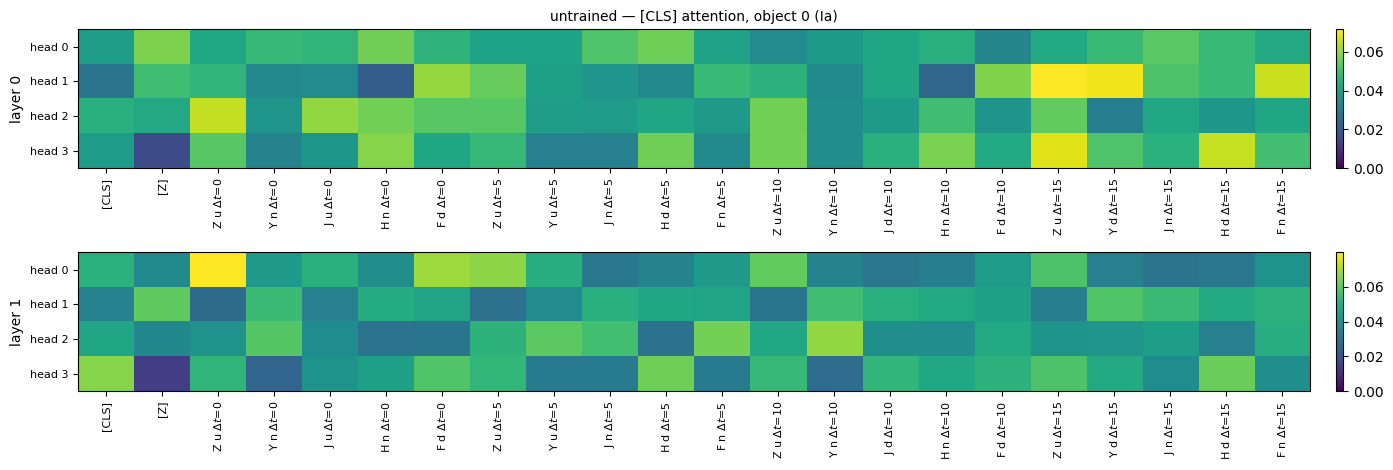

In [9]:
def plot_cls_attention(model, batch, object_index, title_prefix='', plot=True):
    model.eval()
    with torch.no_grad():
        attention_maps = model.attention_maps(batch)

    keep = ~batch['padding_mask'][object_index]
    sequence_valid = torch.cat([torch.ones(2, dtype=torch.bool), keep])
    key_labels = ['[CLS]', '[Z]']
    for band_index, token_type_index, delta_time in zip(
        batch['band_index'][object_index][keep].numpy(),
        batch['token_type_index'][object_index][keep].numpy(),
        batch['delta_time'][object_index][keep].numpy(),
    ):
        key_labels.append(f'{BAND_ORDER[band_index]} {TOKEN_TYPE_ORDER[token_type_index]} '
                          rf'$\Delta t$={delta_time:.0f}')

    cls_attention_per_layer = [
        layer_attention[object_index, :, 0, :][:, sequence_valid].numpy()
        for layer_attention in attention_maps
    ]
    number_of_layers = len(cls_attention_per_layer)

    if plot:
        figure, axes = plt.subplots(number_of_layers, 1,
                                    figsize=(0.55 * len(key_labels) + 2, 2.4 * number_of_layers),
                                    squeeze=False)
        for layer_index in range(number_of_layers):
            axis = axes[layer_index][0]
            image = axis.imshow(cls_attention_per_layer[layer_index], cmap='viridis', vmin=0.0, aspect='auto')
            axis.set_yticks(range(NUM_HEADS))
            axis.set_yticklabels([f'head {head_index}' for head_index in range(NUM_HEADS)], fontsize=8)
            axis.set_xticks(range(len(key_labels)))
            axis.set_xticklabels(key_labels, rotation=90, fontsize=8)
            axis.set_ylabel(f'layer {layer_index}')
            plt.colorbar(image, ax=axis, fraction=0.025, pad=0.02)
        axes[0][0].set_title(f'{title_prefix}[CLS] attention, object {object_index} '
                             f'({GROUP_ORDER[int(batch["label"][object_index])]})', fontsize=10)
        plt.tight_layout()
        plt.show()
    return cls_attention_per_layer


_ = plot_cls_attention(model, batch, EXAMPLE_INDEX, title_prefix='untrained — ', plot=True)

## 8 — Sanity check: overfit one batch

Before any real training, the standard check that an architecture is wired correctly is to
**overfit a single batch**: with enough steps the loss should collapse to ~0 and the training
accuracy hit 100%. If it cannot memorize 8 examples, something is broken (a detached gradient, a
mask that hides everything, a shape bug) — no amount of data would fix it.

This is *not* a result. It says nothing about generalization; it only proves gradients flow end
to end and the model has the capacity to fit.

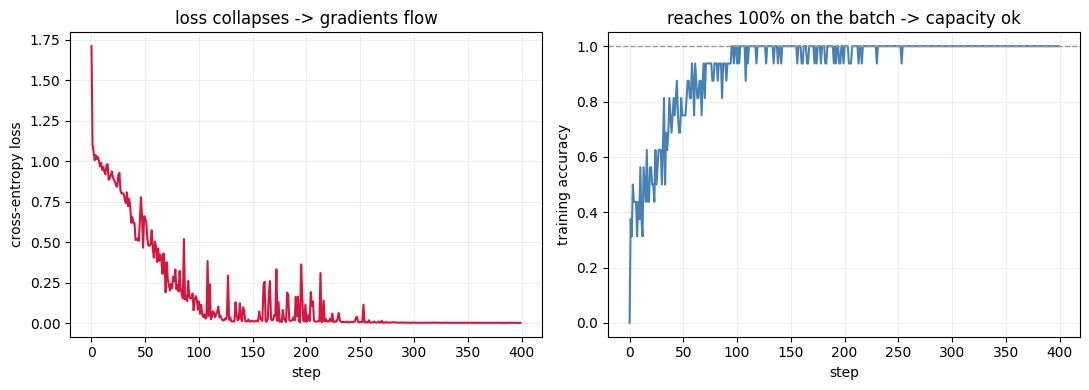

final loss 0.0017   final accuracy 1.00


In [10]:
def overfit_one_batch(model, batch, number_of_steps=400, learning_rate=1e-3, plot=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    labels = batch['label']
    loss_history = []
    accuracy_history = []
    model.train()
    for step in range(number_of_steps):
        optimizer.zero_grad()
        logits = model(batch)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        loss_history.append(float(loss.detach()))
        accuracy_history.append(float((logits.argmax(dim=-1) == labels).float().mean()))
    if plot:
        figure, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(loss_history, color='crimson')
        axes[0].set_xlabel('step')
        axes[0].set_ylabel('cross-entropy loss')
        axes[0].set_title('loss collapses -> gradients flow')
        axes[0].grid(alpha=0.2)
        axes[1].plot(accuracy_history, color='steelblue')
        axes[1].axhline(1.0, color='0.6', ls='--', lw=1)
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('training accuracy')
        axes[1].set_ylim(-0.05, 1.05)
        axes[1].set_title('reaches 100% on the batch -> capacity ok')
        axes[1].grid(alpha=0.2)
        plt.tight_layout()
        plt.show()
    return loss_history, accuracy_history


overfit_model = KilonovaTransformer()
loss_history, accuracy_history = overfit_one_batch(overfit_model, batch, plot=True)
print(f'final loss {loss_history[-1]:.4f}   final accuracy {accuracy_history[-1]:.2f}')

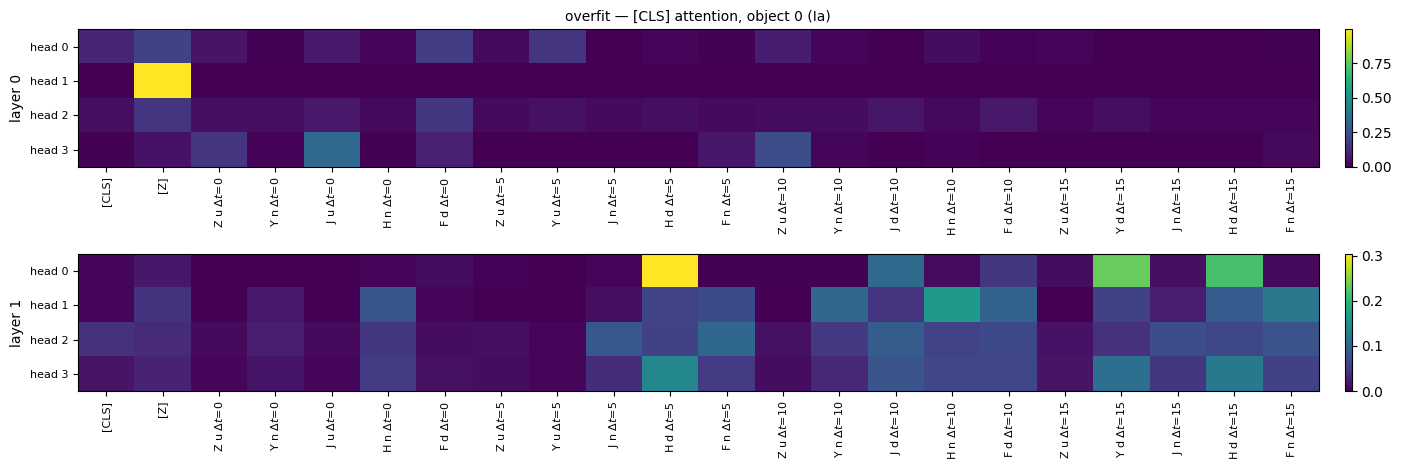

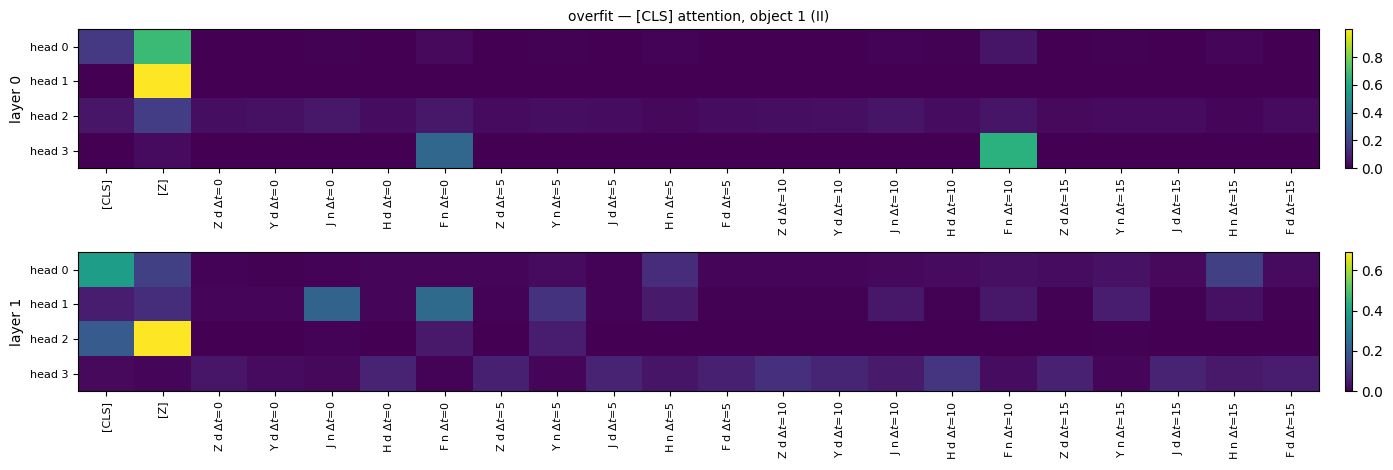

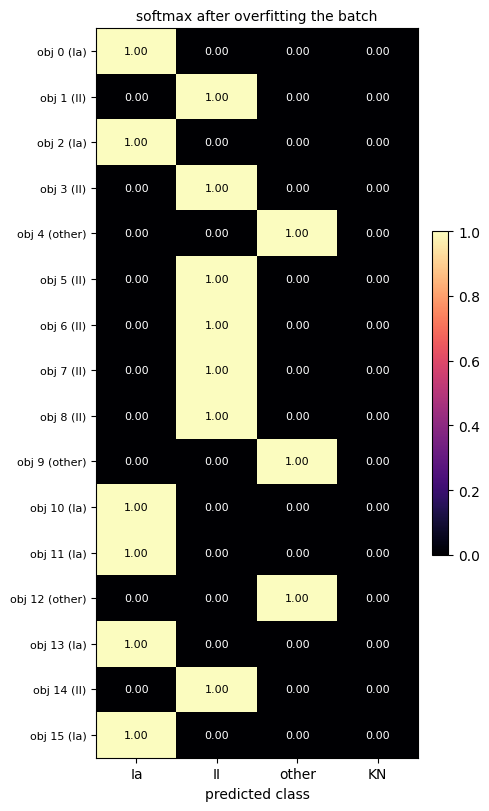

In [11]:
# now that the model has fit the batch, the [CLS] attention is structured: compare the
# fast fader against the slow supernova.
_ = plot_cls_attention(overfit_model, batch, EXAMPLE_INDEX, title_prefix='overfit — ', plot=True)
_ = plot_cls_attention(overfit_model, batch, EXAMPLE_INDEX_B, title_prefix='overfit — ', plot=True)
_ = plot_class_probabilities(overfit_model, batch, title='softmax after overfitting the batch', plot=True)

## Recap and next steps

We built, from scratch, the encoder-only transformer the plan calls for:

- tokens as a **set** indexed by physical time — **time2vec** instead of positional encoding,
  with the **linear (decline-rate) term** doing the work and only a few low-frequency sinusoids
  (no Fourier modulation, by design, for a 3-epoch problem);
- a **type embedding** over `{d, u, n}` carrying the detection / non-detection structure;
- learned **`[CLS]`** and **`[Z]`** global tokens — `[Z]` is the continuous z plus a
  `{low, high, unknown}` regime embedding (the `unknown` regime is the z-dropout / `[NO_Z]`
  occultation);
- pre-LayerNorm encoder blocks, `[CLS]` read-out → 4-class head;
- a forward pass on the **real OpenUniverse batch** (`openuniverse_dataset.py`), an interpretable
  `[CLS]`-attention view, and an overfit-one-batch proof that the wiring learns.

**Next notebook (training):**

1. Train on the real `train_loader` / `validation_loader` from `openuniverse_dataset.py` (the
   placeholder sample grows first).
2. Add the on-the-fly **KN twin generation** matched to each low-z contaminant (the matched-twin
   construction in `plan.md`).
3. Train with **random prefix truncation** (epochs 1 / 1–2 / full) and **z-regime dropout** (flip
   `redshift_regime` to `unknown`).
4. Produce the **degradation matrix** — recall at a fixed candidate budget × {epoch 1, 2, 3} ×
   {spec-z, photo-z, no z} — the paper's key figure.